# Lecture 19 Rossby deformation radii and EKE in MPAS-Ocean simulations

1) Check if the deformation radius and EKE are already MPAS-O outputs
2) Estimate the time-mean first baroclinic Rossby radius for all cells in an unstructured grid, assuming a thermocline scale height of H=700m (and using the average density stratification over that layer). [A more rigorous calculation would solve an eigenvalue problem for each density profile]
3) Use horizontal speed or velocity outputs interpolated to cell centers (either already available or computed yourself) to make maps of surface mean kinetic energy and eddy kinetic energy (based on eddy velocities diagnosed by subtracting the time mean)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpas_tools
import dask

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

from dask.diagnostics import ProgressBar

import geojson
import json
import mosaic
import os.path
import mpasregions.sections as mps
import gsw
import warnings 
import glob
from xgcm import Grid


## Determine how data shoudl be chunked

In [5]:
# write an ungerneralized function to calculate the number of chunks required
def calculate_elements_per_chunk(ds, chunk_over_dim, datavariable, convert_to):
    # look at a single element of the datavariable you are interested in
    # chunk_over_dim0 = {chunk_over_dim : 0}
    single_element = ds[datavariable]#.isel(chunk_over_dim0)

    # calculate the total number of values in this single element of the datavariable
    dim_length_product = 1
    for i in single_element.dims:
        dim_length = len(single_element[i])
        dim_length_product = dim_length * dim_length_product

    # calculate the total number of bits in this single element of the datavariable
    # each value is either 32 (single-precision) or 64 (double-precision) bits
    if single_element.dtype == 'float32':
        bits_per_value = 32
    if single_element.dtype == 'float64':
        bits_per_value = 64

    total_bits = dim_length_product * bits_per_value

    # convert the total number of bits to bytes... 8 bits / 1 byte and 10^9 bytes/ 1 GB or 10^6 bytes / 1 MB
    if convert_to == 'MB':
        conversion_factor = 10**6
        memory_per_chunk = 50
    if convert_to == 'GB':
        conversion_factor = 10**9
        memory_per_chunk = 50 * 10**(-3) # chunk size 50 MB converted to GB
        
    memory_per_datavariable = total_bits / (8 * conversion_factor)
    print(f'ds.{datavariable} {memory_per_datavariable} {convert_to} of memory.')

    # now determine how many chunks are required to feasibly load data (we are aiming for 50 MB of memory per chunk slice)
    number_of_chunks = np.round(memory_per_datavariable / memory_per_chunk)

    # determine the number of data elements in each chunk
    elements_per_chunk = int(len(ds[chunk_over_dim]) / number_of_chunks)
    
    print(f'We need {number_of_chunks} chunks along the {chunk_over_dim} dimension to feasibly load ds.{datavariable}')
    print(f'Each chunk contains about {elements_per_chunk} elements')

    return elements_per_chunk

In [6]:
# to open a dataset
# Step 0: Decide if you want HR or LR
HR = True

if HR == True:
    prefix = '20210421_sim7_CORE_18to6v3.mpaso.hist.am.timeSeriesStats'
    bmm_filepath = '/pscratch/sd/b/bmoorema/run_021_030/'
    year = 25
    mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/oRRS18to6v3/oRRS18to6v3.171116.nc'


if HR == False: # LR
    prefix = '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStats'
    bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'
    year = 63 # aka 2009
    mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'

    
    
# Step 1: open the dataset using an arbitrarily large number of chunks so that it opens faster
with ProgressBar():
    # open the mesh
    mesh = xr.open_dataset(mesh_path)
    mesh = mesh.assign_coords({
    "VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
    })
        
    # open datasets with just the variables that we want
    
    months = ['01','02','03','04','05','06','07','08','09','10','11','12']
    ds_list = []

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i in range(0,12):
            month = months[i]
            file = prefix + f'Monthly.{str(year).zfill(4)}-{month}-01.nc'
            file_glob = glob.glob(file)

            ds = xr.open_dataset(bmm_filepath + file, chunks={})[['xtime_startMonthly','timeMonthly_avg_potentialDensity','timeMonthly_avg_layerThickness',
                                                       'nCells','nEdges','nVertLevels','nVertLevelsP1','timeMonthly_avg_velocityZonal','timeMonthly_avg_velocityMeridional',
                                                       'timeMonthly_avg_velocityZonalSquared','timeMonthly_avg_velocityMeridionalSquared','timeMonthly_avg_daysSinceStartOfSim',
                                                       'timeMonthly_avg_BruntVaisalaFreqTop']]
            ds_xtime_startMonthly = ds.swap_dims({'Time':'xtime_startMonthly'})
            ds_list.append(ds_xtime_startMonthly)
    
    print('opened. beginning concatenation')
    dss = xr.concat(ds_list,dim='xtime_startMonthly').chunk({'xtime_startMonthly':-1})
    ds = mps.add_grid_info_coords(mesh,dss)
    
    # convert from nanosectonds to seconds
    secs_since_start = ds.timeMonthly_avg_daysSinceStartOfSim / 10**9
    
    # convert from seconds to days
    seconds_per_day = 60 * 60 * 24
    days_since_start = secs_since_start / seconds_per_day
    
    # assign weights to each value 
    # 31 is the number of days between 12-15-62 and 01-15-63 that is stored in 01-01-63
    weights = np.append(np.array([31]), np.int32(np.diff(days_since_start)))

# Step 2: determine what the chunk sizes actually should be, based on the size of a single datavariable
# this isn't the cleanest thing way to do it (since it's all based on the size of a single variable, even though we are extracting multiple datavariables...
chunk_over_dim = 'nCells'
datavariable = 'timeMonthly_avg_potentialDensity'
convert_to = 'MB'
elements_per_chunk = calculate_elements_per_chunk(ds, chunk_over_dim, datavariable, convert_to)

# Step 3: unchunk the arbitrarily chunked dataset using a .compute(). rechunk using the correctly calculated elements_per_chunk
with ProgressBar():
    ds_chunked = ds.chunk({'nCells':elements_per_chunk})

[########################################] | 100% Completed | 102.16 ms
[########################################] | 100% Completed | 101.01 ms
[########################################] | 100% Completed | 101.03 ms
[########################################] | 100% Completed | 101.38 ms
[########################################] | 100% Completed | 100.96 ms
[########################################] | 100% Completed | 101.46 ms
[########################################] | 100% Completed | 101.13 ms
[########################################] | 100% Completed | 101.63 ms
[########################################] | 100% Completed | 101.49 ms
[########################################] | 100% Completed | 100.98 ms
[########################################] | 100% Completed | 101.45 ms
[########################################] | 100% Completed | 101.48 ms
opened. beginning concatenation
[########################################] | 100% Completed | 101.72 ms
ds.timeMonthly_avg_potentialDens

In [7]:
ds = ds_chunked

In [8]:
# # search for variables
# for i in dso.data_vars:
#     if 'Vais' in i:
#         print(i)

## Time-Averaged First Baroclinic Rossby Radius

### Background on baroclinic modes
Consider a stratified fluid. The different mean horizontal velocities throughout the water column (baroclinic flow) produce a vertical shear that leads to baroclinic instabilities. These instabilities can be described with baroclinic modes that describe how the perturbed horizontal velocity structure changes in the vertical direction. 

>- We define velocity to be $\mathbf{u} = \overline{\mathbf{u}} + \mathbf{u^\prime}$
>- $\mathbf{u}$ is the total velocity
>- $\overline{\mathbf{u}}$ is the mean velocity (the background state of vertical shear exists in the system because there are different mean velocities for different density classes (i.e., $\frac{\partial \overline{\mathbf{u}}}{\partial z} \neq 0$) that allow for the formation of baroclinic instabilities)
>- $\mathbf{u^\prime}$ is is the perturbation from the mean produced by the vertical shear and whose vertical structure is described by baroclinic modes. 

In a 2-layer model, there is one baroclinic mode (the vertical structure of the baroclinic instabilities can be described by a single eigenfunction). There are only 2 densities in the system ($\rho_1$ for Layer 1 and $\rho_2$ for Layer 2) The baroclinic mode has a deformation radius $L_d$ that represents the length scale at which effects of Coriolis on dynamics are equal to that of gravity (stratification). 

>- If the characteristic length scale $L$ is *smaller* than $L_d$, then stratification/buoyancy has a greater effect on flow structure.
>- If the characteristic length scale $L$ is *larger* than $L_d$, then rotation has a greater effect on flow structure. 

*SIDEBAR: If we were to assume a continuous stratification, then we use $L_d \sim \frac{NH}{f}$ where $N$ is the buoyancy / Brunt-Vaisala frequency, $H$ is the scale height, and $f$ is the Coriolis parameter.*

### Problem set-up
Since the pycnocline is narrow, and the variation in density at depths above and below it is small, we can treat the ocean as a 2-layer shallow water system (baroclinic). 

The baroclinic deformation radius in a 2-layer shallow-water system is 
\begin{equation}
    L_d = \frac{\sqrt{g^\prime H_1}}{f_0} 
\end{equation}

where $\rho_1$ is the average density above the pycnocline and $\rho_2$ is the average density below the pycnocline and the reduced gravity is defined to be $g^\prime = g\frac{\rho_2 - \rho_1}{\rho_1}$ (Vallis pg 111). For now, we let the pycnocline depth be 700m. This means $H_1 = 700\, m$.

If we were to calculate the pycnocline depth for every grid cell (rather than assume it is at 700m), then we would look at the peak (largest value) of $N$, which is the buoyancy/Brunt-Vaisala frequency $\left(N = \sqrt{-\frac{g}{\rho_0} \frac{\partial \rho (z)}{\partial z}} \right)$. The depth of the $N_{max}$ is the depth of the largest change in density $\rho (z)$ with respect to depth ($z$), which is the pycnocline location.

In [9]:
with ProgressBar():
    # remove nans condition
    remove_nans = (ds.timeMonthly_avg_potentialDensity > 1000) & (ds.timeMonthly_avg_layerThickness > 0)
    
    # separate level 1 from level 2
    ds['depth'] = ds.timeMonthly_avg_layerThickness.cumsum(dim='nVertLevels')
    ds_layer1_potentialDensity = ds.timeMonthly_avg_potentialDensity.where((ds.depth < 700) & remove_nans)
    ds_layer2_potentialDensity = ds.timeMonthly_avg_potentialDensity.where((ds.depth >= 700) & remove_nans)
    
    # calculate the average potential density of layer 1
    rho_1 = ds_layer1_potentialDensity.mean(dim=('nVertLevels')) 
    rho_2 = ds_layer2_potentialDensity.mean(dim=('nVertLevels'))
    
    # calculate gprime
    g_prime = 9.81 * (rho_2 - rho_1) / rho_1
    
    # define pycnocline depth
    H_1 = 700
    
    # define f (coriolis parameter
    f = np.abs(ds.fCell.where(remove_nans).isel(nVertLevels=0))
    
    # calculate baroclinic deformation radius
    L_d = np.sqrt(g_prime * H_1) / f
    L_d_km = L_d / 1000
    
    # take the weighted mean over time
    weights_L_d_km_ds = xr.zeros_like(L_d_km.isel(nCells=0)) + weights
    
    # multiply the weights by each L_d value
    weighted_L_d_km = L_d_km * weights_L_d_km_ds
    
    # calculate the weighted annual average
    mean_L_d_km_64 = weighted_L_d_km.sum(dim='xtime_startMonthly') / 365
    
    # convert from float64 to float32
    mean_L_d_km = mean_L_d_km_64.astype(np.float32)

[########################################] | 100% Completed | 808.46 ms
[########################################] | 100% Completed | 101.34 ms
[########################################] | 100% Completed | 908.70 ms
[########################################] | 100% Completed | 101.28 ms
[########################################] | 100% Completed | 908.63 ms
[########################################] | 100% Completed | 101.29 ms
[########################################] | 100% Completed | 908.04 ms
[########################################] | 100% Completed | 101.89 ms
[########################################] | 100% Completed | 807.20 ms
[########################################] | 100% Completed | 101.27 ms
[########################################] | 100% Completed | 506.08 ms
[########################################] | 100% Completed | 101.08 ms
[########################################] | 100% Completed | 1.10 sms
[########################################] | 100% Completed | 100

/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in sqrt
  return self.func(*new_argspec)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in sqrt
  return self.func(*new_argspec)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


In [10]:
plot_this = mean_L_d_km.compute()

Text(0.5, 1.0, 'Time-Averaged First Baroclinic Rossby Deformation Radius \n H=700m')

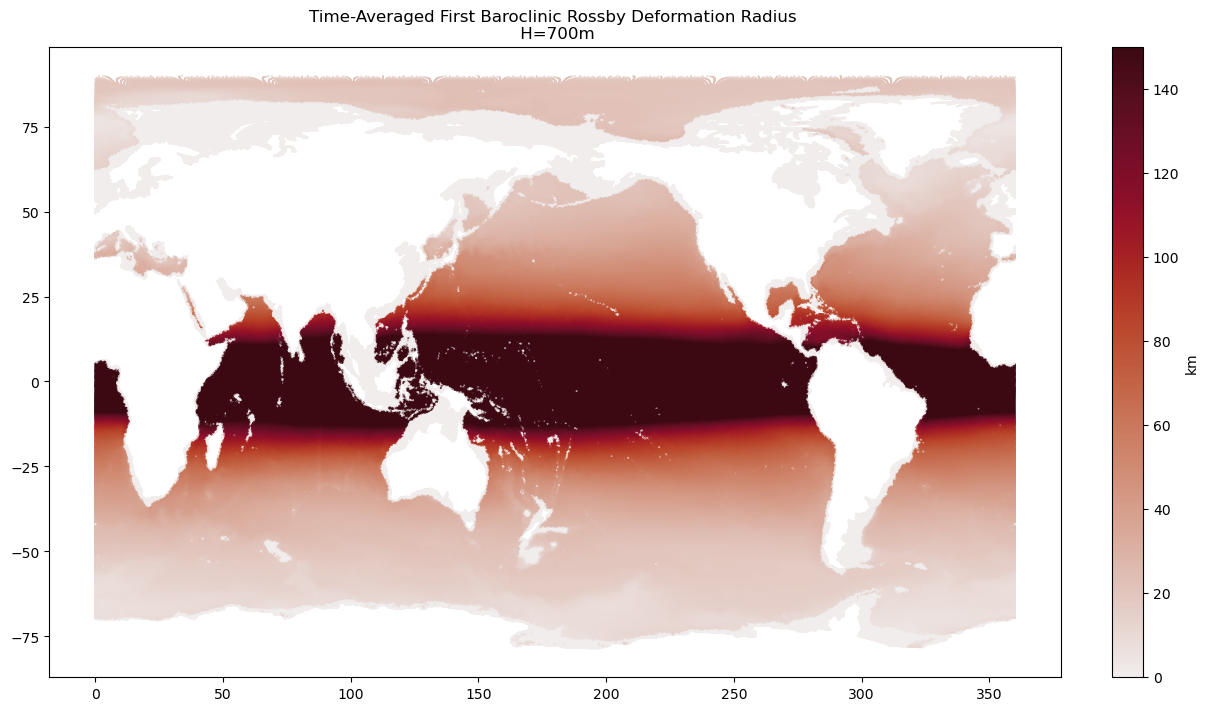

In [11]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))
# plot_this = mean_L_d_km.compute()
# im = ax.scatter(mesh.lonCell, mesh.latCell, c=plot_this, s=0.1, vmin=plot_this.min(),vmax=plot_this.max(), cmap=cmo.haline)
im = ax.scatter(np.rad2deg(mesh.lonCell), np.rad2deg(mesh.latCell), c=plot_this, s=0.1, vmin=0,vmax=150, cmap=cmo.amp)

fig.colorbar(im, ax =ax, label='km')
ax.set_title('Time-Averaged First Baroclinic Rossby Deformation Radius \n H=700m')

$L_d$ tells us the scale at which the flow will become dominated by Coriolis forces over stratification. 
However, this information is only useful if we can compare it to the characteristic scale of the flow $L$. 
## Ratio of characteristic length scale to Rossby deformation radius.
The MPAS-Ocean high-resolution dataset has 6-18km horizontal grid resolution. If we assume the length of these grid cells represents the characteristic length scale $L$, then we can compare $L$ to $L_d$ to see which regions the flow is dominated by Coriolis effects compared to stratification (gravity) effects. 

**Note** \
MPAS-Ocean is has an unstructured grid. This means that instead of having rectangular horizontal grid cells, the grid cells are 5-, 6-, or 7-sided polygons. The edges of grid cells do not follow lines of longitude or latitude in the way that structured grid cells do. As a result, to find the horizontal length scale, we assume the polygon is a circle and find its diameter. 


In [13]:
# calculate the length scale from the area of the polygon
area = ds.areaCell

# Assuming the polygon is convex s.t. a circle can be inscribed in it, then the Area_polygon = Area_circle = pi*r^2
# solve for r
r = np.sqrt(area / np.pi) 

# solve for the diameter of the circle to get an approximate length scale L
# convert from m to km
d = 2*r
L_km = d / 1000

# compare the length scale to the baroclinic rossby deformation radius
L_L_d_ratio = L_km / mean_L_d_km

Text(0.5, 1.0, 'Time-Averaged $L/L_d$ \n H=700m')

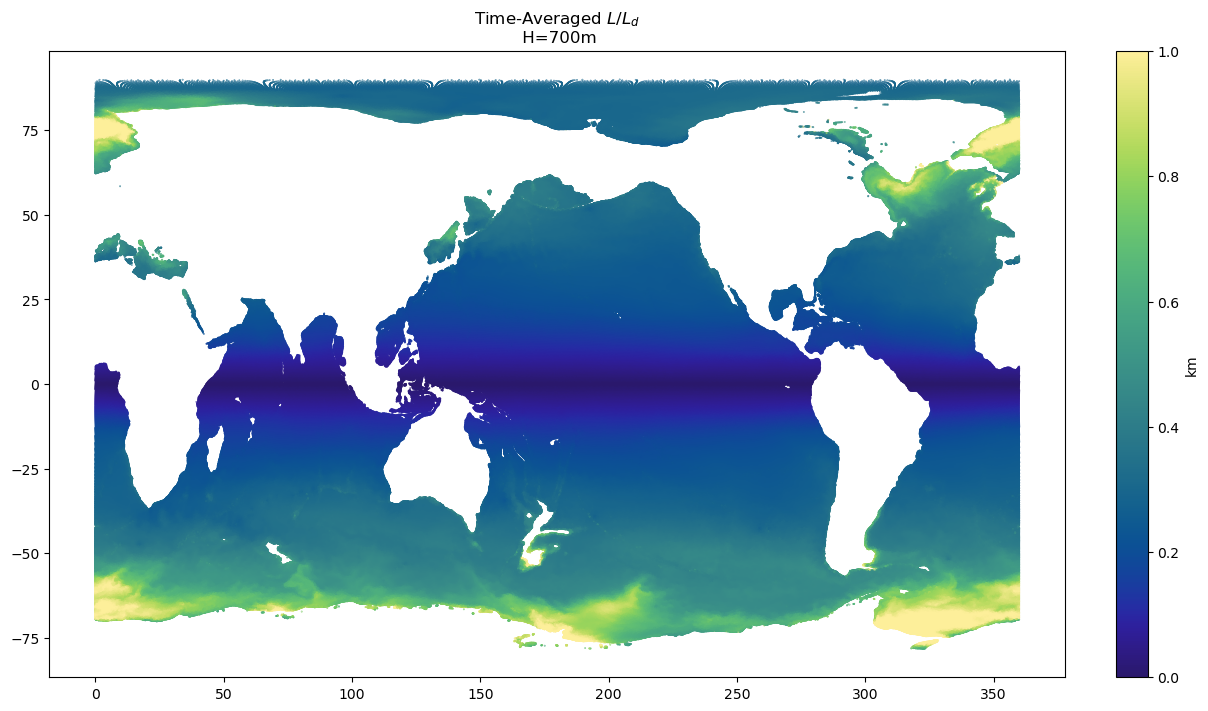

In [14]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))
im = ax.scatter(np.rad2deg(mesh.lonCell), np.rad2deg(mesh.latCell), c=L_L_d_ratio, s=0.1, vmin=0,vmax=1, cmap=cmo.haline)

fig.colorbar(im, ax =ax, label='km')
ax.set_title('Time-Averaged $L/L_d$ \n H=700m')

>- The dark blue represents areas where $L < L_d$. The flow is dominated by stratification effects.
>- The yellow represents areas where $L > L_d$. The flow is dominated by Coriolis effects.


## Time-averaged KE, MKE, EKE plots
Assume hydrostatic balance where the vertical velocity $w$ is negligibly small.

KE is kinetic energy, MKE is mean kinetic energy, EKE is eddy kinetic energy. 

\begin{align}
    KE &= \frac{1}{2}\vec{u}^2 \\
    KE &= \frac{1}{2}\left(\langle u,v\rangle \cdot \langle u, v \rangle \right) \\
    KE &= \frac{1}{2}\left(u^2 + v^2\right) \tag{1}
\end{align}

To separate out mean kinetic energy ("mean" as in the mean flow, not time mean), we do a Reynolds decomposition such that
\begin{align}
    u = &\overline{u} + u^\prime \\
    \text{where } &\overline{u} \, \text{is the mean flow and} \\
    &u^\prime \, \text{is the perturbation from the mean} \\
    \implies & \overline{u^\prime}=0
\end{align}

Plug in the Reynolds decomposion to Equation 1.
\begin{align}
    KE &= \frac{1}{2} \left(\left(\overline{u}+u^\prime\right)^2 + (\left(\overline{v}+v^\prime\right)^2 \right) \\
    KE &= \frac{1}{2} \left(\overline{\overline{u}^2} + \overline{2 \overline{u}u^\prime} +\overline{u^{\prime ^2}} + \overline{\overline{v}^2} + \overline{2 \overline{v}v^\prime} +\overline{v^{\prime ^2}} \right) \\
    KE &= \frac{1}{2} \left(\overline{u}^2 + \cancelto{0}{2\overline{u}\overline{u^\prime}} + \overline{u^{\prime ^2}} + \overline{v}^2 + \cancelto{0}{2\overline{v}\overline{v^\prime}} + \overline{v^{\prime ^2}}\right) \\
    KE &= \frac{1}{2} \left(\overline{u}^2 + \overline{v}^2 + \overline{u^{\prime ^2}} + \overline{v^{\prime ^2}}\right) \tag{2}
\end{align}

*Terms 2 and 5 cancel to 0 because $2$ and $\overline{u}$ can be pulled out since they are constants. And then, by defintion, $\overline{u^\prime} = 0$.*

Separately, we define the following relationships for KE.
\begin{align}
    KE &= MKE + EKE \\
    \implies \overline{KE} &= \overline{MKE} + \overline{EKE} \tag{3}
\end{align}

MKE emerges from the mean flow $\langle \overline{u},\overline{v} \rangle$ and EKE emerges from the perturbation from the mean flow $\langle u^\prime, v^\prime \rangle$.

Setting Equations 2 and 3 equal to each other, we get the following.
\begin{equation}
    \overline{KE} = \underbrace{\frac{1}{2} \left( \overline{u}^2 + \overline{v}^2 \right)}_{\overline{MKE}} + \underbrace{\frac{1}{2} \left( \overline{u^{\prime ^2}} + \overline{v^{\prime ^2}} \right)}_{\overline{EKE}} \tag{4}
\end{equation}

Given this set up, we now want an equation for $\overline{MKE}$ and $\overline{EKE}$ from the diagnostics available in MPAS-Ocean. The first term in Equation 4 can be used to solve for $\overline{MKE}$ because we have $u$ and $v$ diagnostics available. However, the second term in Equation 4 cannot be used to solve for $\overline{EKE}$ because we do not have $u^\prime$ and $v^\prime$ diagnostics available. Luckily we do have diagnostics for $u^2$ and $v^2$, so we can rearrange Equation 3 and plug in Equations 1 and 4 ($\overline{MKE}$ expression) to find a way to calculate $\overline{EKE}$ from mean flow. Note that the overlines now represent a *time-average*.

\begin{align}
    KE &= \frac{1}{2} \left(u^2 + v^2 \right) \\
    \overline{KE} &= \frac{1}{2} \left(\overline{u^2 + v^2} \right) \\
    \implies \overline{EKE} &= \overline{KE} - \overline{MKE} \\
    \overline{EKE} &= \frac{1}{2} \left(\overline{u^2 + v^2} \right) - \frac{1}{2}\left(\overline{u}^2 + \overline{v}^2\right)
\end{align}

One thing to note is that we end up taking a time-average over the entire year. Output data is a monthly-average for the days in [Month n, Day 15 to Month n+1, Day 15), stored on Month n, Day 01. The exception is in February, when the days range from [01-15, 02-14) stored on 02-01 and from [02-14, 03-15) stored on 03-01. We weight these monthly averages by the number of days in the "month" [Month n, Day 15 to Month n+1, Day 15).

\begin{equation}
    \overline{\chi} = \frac{\sum_{i=1}^{12} w_i \times \chi_i}{\sum w_i = 365}
\end{equation}

where $w$ represents the weights (days in a month) and $\chi$ is the calculated energy at the surface (`nLevels=0`) for each of the grid cells.

In [15]:
# calculate mean KE
u2plusv2 = (ds.timeMonthly_avg_velocityZonalSquared + ds.timeMonthly_avg_velocityMeridionalSquared).isel(nVertLevels=0)

# calculate the weights
weights_u2plusv2_ds = xr.zeros_like(u2plusv2.isel(nCells=0)) + weights

# multiply the weights by each u2plusv2 value
weighted_u2plusv2 = (u2plusv2 * weights_u2plusv2_ds)

# calculate the weighted annual average
mean_u2plusv2 = weighted_u2plusv2.sum(dim='xtime_startMonthly') / 365

# calculate the mean KE
mean_KE = 0.5 * mean_u2plusv2
mean_KE_cm2 = mean_KE * 10000

Text(0.5, 1.0, 'Time-Averaged Kinetic Energy \n$\\overline{KE} = \\frac{1}{2} \\left(\\overline{u^2 + v^2} \\right)$')

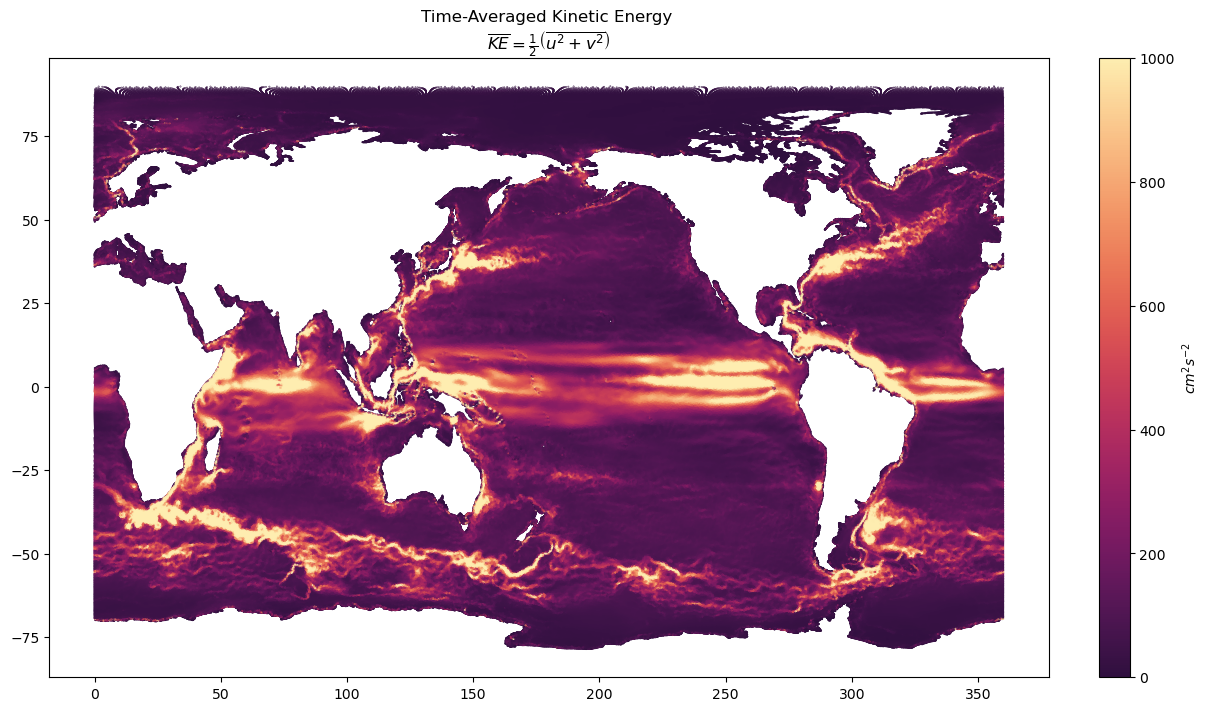

In [25]:
# plot mean_KE
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))
im = ax.scatter(np.rad2deg(mesh.lonCell), np.rad2deg(mesh.latCell), c=mean_KE_cm2, s=0.1, vmin=0,vmax=1000, cmap=cmo.matter_r)

fig.colorbar(im, ax =ax, label='$cm^2 s^{-2}$')
ax.set_title('Time-Averaged Kinetic Energy \n'+ r'$\overline{KE} = \frac{1}{2} \left(\overline{u^2 + v^2} \right)$')

In [17]:
# calculate mean_MKE
u = ds.timeMonthly_avg_velocityZonal.isel(nVertLevels=0)
v = ds.timeMonthly_avg_velocityMeridional.isel(nVertLevels=0)

# calculate the weights
weights_u_ds = xr.zeros_like(u.isel(nCells=0)) + weights
weights_v_ds = xr.zeros_like(v.isel(nCells=0)) + weights

# multiply the weights by each u value
weighted_u = u * weights_u_ds
weighted_v = v * weights_v_ds

# calculate the weighted annual average
mean_u = weighted_u.sum(dim='xtime_startMonthly') / 365
mean_v = weighted_v.sum(dim='xtime_startMonthly') / 365

# calculate the mean MKE
mean_MKE = 0.5 * (mean_u**2 + mean_v**2)
mean_MKE_cm2 = mean_MKE * 10000

Text(0.5, 1.0, 'Time-Averaged Mean Kinetic Energy \n$\\overline{MKE} = \\frac{1}{2} \\left(\\overline{u}^2 + \\overline{v}^2 \\right)$')

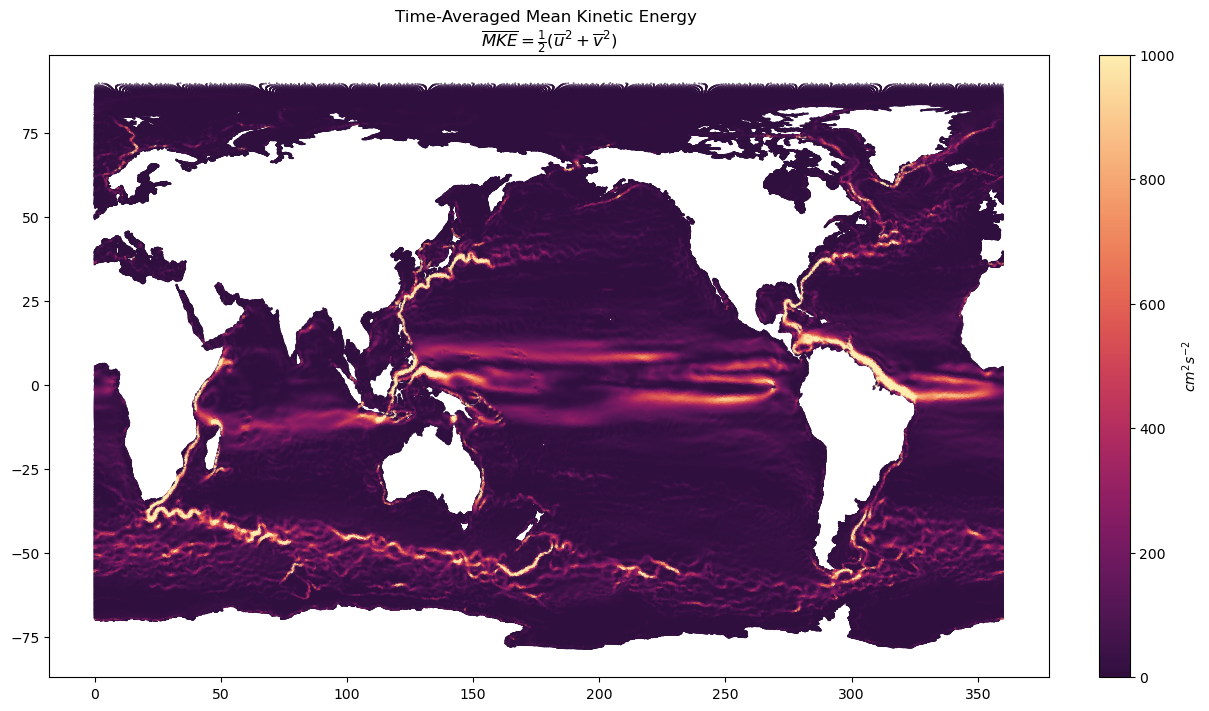

In [26]:
# plot mean_MKE
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))
im = ax.scatter(np.rad2deg(mesh.lonCell), np.rad2deg(mesh.latCell), c=mean_MKE_cm2, s=0.1, vmin=0,vmax=1000, cmap=cmo.matter_r)

fig.colorbar(im, ax =ax, label='$cm^2 s^{-2}$')
ax.set_title('Time-Averaged Mean Kinetic Energy \n' + r'$\overline{MKE} = \frac{1}{2} \left(\overline{u}^2 + \overline{v}^2 \right)$')

In [19]:
# calculate mean EKE
mean_EKE = mean_KE - mean_MKE
mean_EKE_cm2 = mean_EKE * 10000

Text(0.5, 1.0, 'Time-Averaged Eddy Kinetic Energy \n$\\overline{EKE} = \\overline{KE} - \\overline{MKE}$')

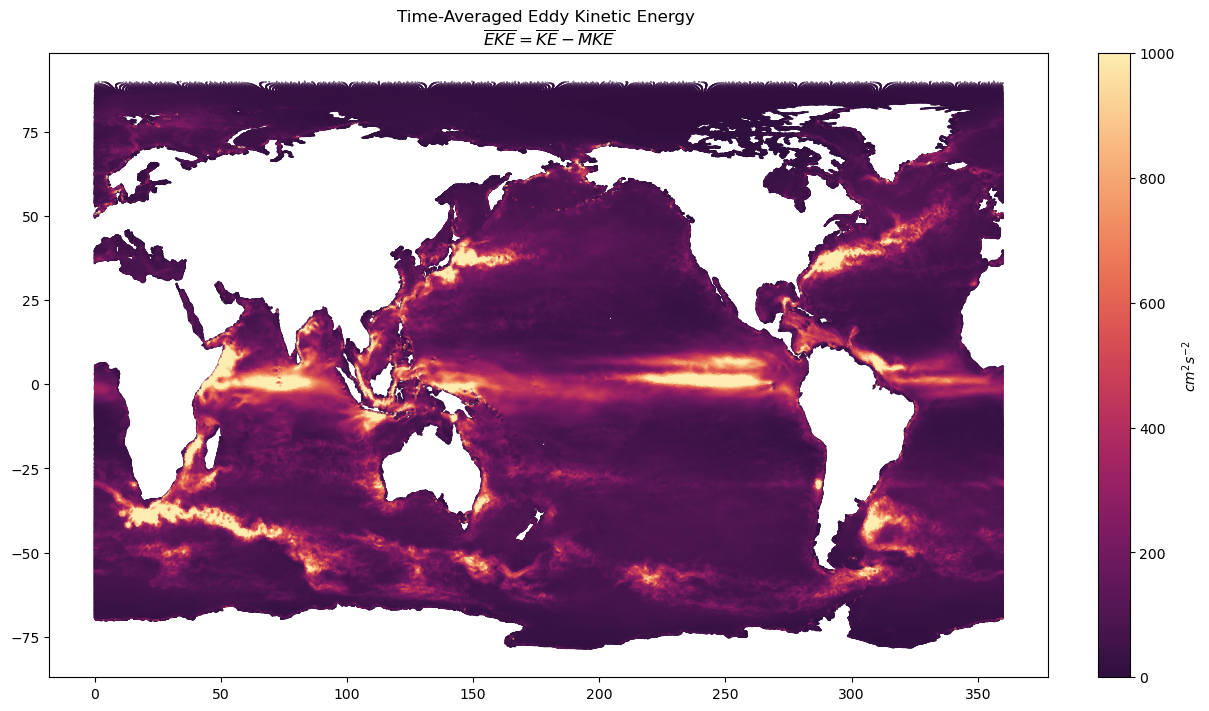

In [27]:
# plot mean_EKE
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))
im = ax.scatter(np.rad2deg(mesh.lonCell), np.rad2deg(mesh.latCell), c=mean_EKE_cm2, s=0.1, vmin=0,vmax=1000, cmap=cmo.matter_r)

fig.colorbar(im, ax =ax, label='$cm^2 s^{-2}$')
ax.set_title('Time-Averaged Eddy Kinetic Energy \n' + r'$\overline{EKE} = \overline{KE} - \overline{MKE}$')

Note that there is a greater amount of EKE in the high-resolution compared to the low-resolution model, particularly in the Southern Ocean. 
This can be attributed to the coarseness of the low-resolution model, where grid cell sizes range from 30-60km. Consider how we have defined the characteristic length scale: $L \approx 2\times \sqrt{\frac{A}{\pi}} \approx \text{grid cell length}$. If flow is dominated by Coriolis force (rotational effects; $L > L_d$), and $L$ is defined as the smallest length scale that can be resolved in the model, then all effects due to stratification $L < L_d$ will not be caputred in the model because that flow is occurring at sub-grid cell lengths. Further, eddies that occur at length scales less than $L$ will also not be captured, resulting in an unrealistically low amount of EKE. 